# ЛАБОРАТОРНА РОБОТА 3.2 

In [158]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## 1. Інвертування зображення, для деякої компонент виконати зміну, виконати розбивку зображення на компоненти Red, Green та Blue, виконати «злиття» двох зображень у певних пропорціях

In [ ]:
def show_image(position, image, title):
    plt.subplot(position)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

In [160]:
def main(img, channel_1, value_1, channel_2, value_2, filename, alpha_1, alpha_2):
    
    invert_img = 255 - img
    
    img1 = img.copy()
    img2 = img.copy()
    
    img1[:, :, channel_1] = np.clip(img1[:, :, channel_1] + value_1, 0, 255)
    img2[:, :, channel_2] = np.clip(img2[:, :, channel_2] + value_2, 0, 255)
    
    red = img.copy()
    green = img.copy()
    blue = img.copy()
    
    red[:, :, [1,2]] = 0  
    green[:, :, [0, 2]] = 0  
    blue[:, :, [0,1]] = 0  
    
    img_merge = cv2.imread(filename)
    img_merge = cv2.cvtColor(img_merge, cv2.COLOR_BGR2RGB)
    
    img_resize = cv2.resize(img, (img_merge.shape[1], img_merge.shape[0]))
    
    img_merge_1, img_merge_2 = np.zeros(img_merge.shape, dtype=np.uint8), np.zeros(img_merge.shape, dtype=np.uint8)

    img_merge_1 = (alpha_1 * img_merge + (1 - alpha_1) * img_resize).astype(np.uint8)
    img_merge_2 = (alpha_2 * img_merge + (1 - alpha_2) * img_resize).astype(np.uint8)
    
    plt.figure(figsize=(12, 5))
    plt.suptitle("Інвертування зображення", fontsize=16)
    show_image(121, img, "Original")
    show_image(122, invert_img, "Invert")

    plt.figure(figsize=(12, 5))
    plt.suptitle("Зміна значень кольорових каналів", fontsize=16)
    show_image(121, img1, f"Channel {channel_1} + {value_1}")
    show_image(122, img2, f"Channel {channel_2} + {value_2}")

    plt.figure(figsize=(12, 8))
    plt.suptitle("Розбивка зображення на компоненти Red, Green та Blue.", fontsize=16)
    show_image(221, img, "Original")
    show_image(222, red, "Red")
    show_image(223, green, "Green")
    show_image(224, blue, "Blue")

    plt.figure(figsize=(12, 8))
    plt.suptitle("Злиття зображень", fontsize=16)
    show_image(221, img_resize, "First image")
    show_image(222, img_merge, "Second image")
    show_image(223, img_merge_1, f"Alpha = {alpha_1}")
    show_image(224, img_merge_2, f"Alpha = {alpha_2}")

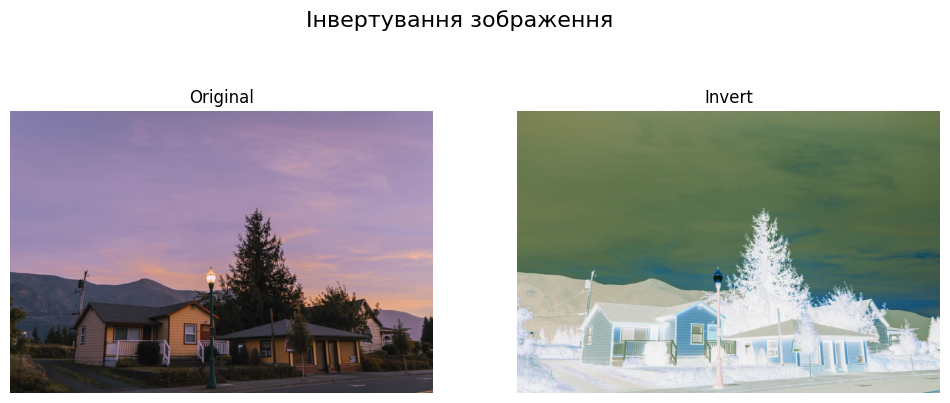

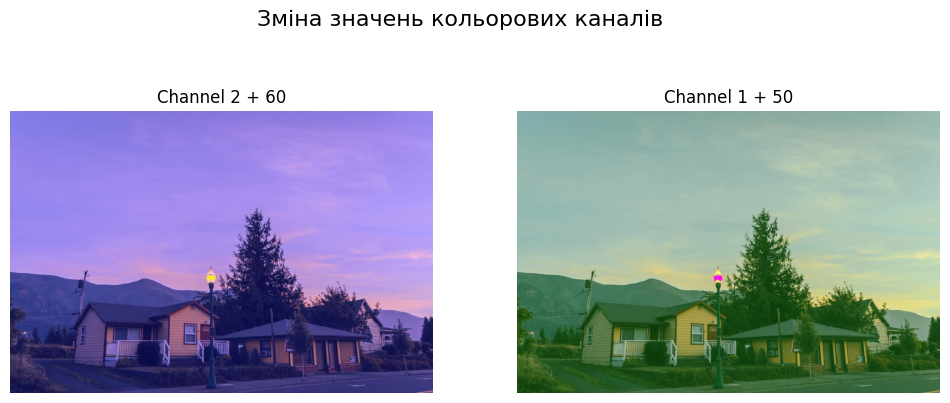

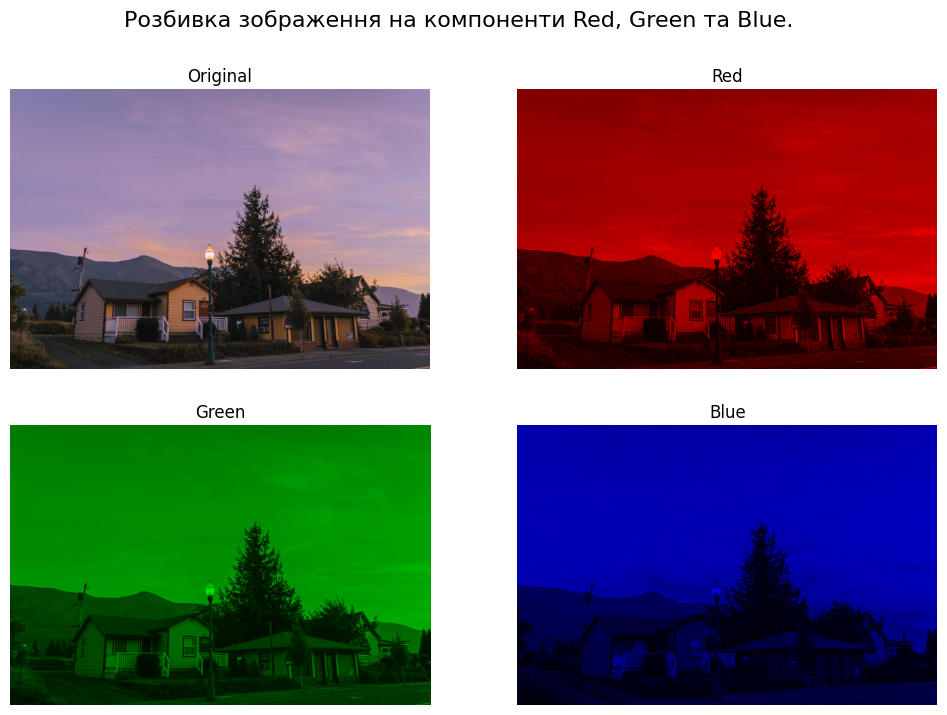

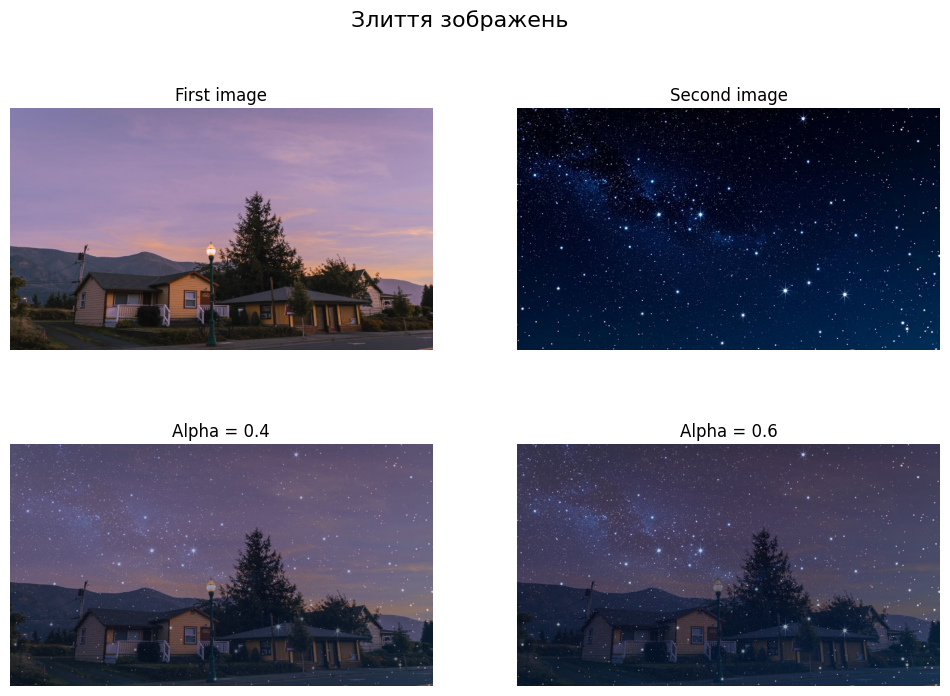

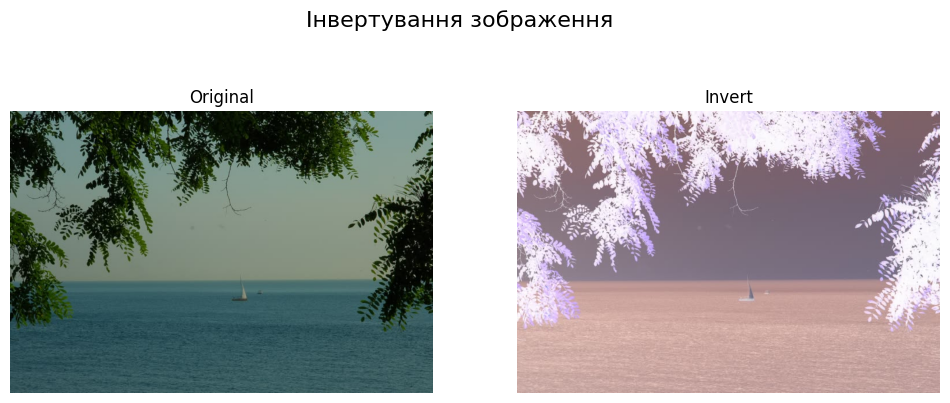

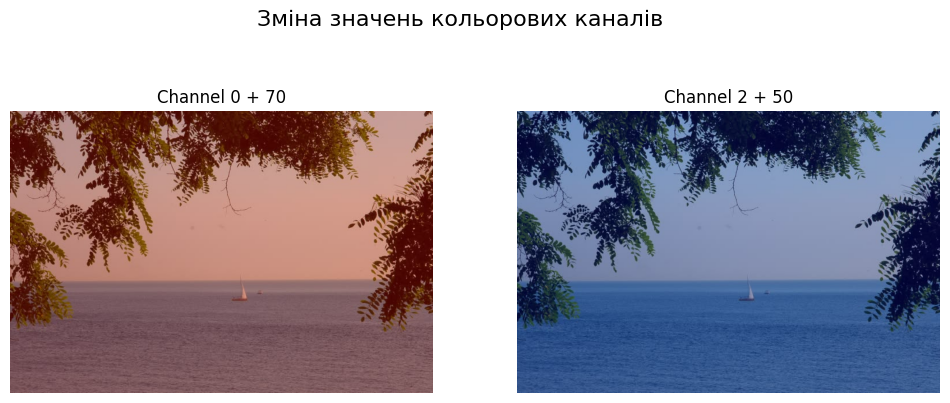

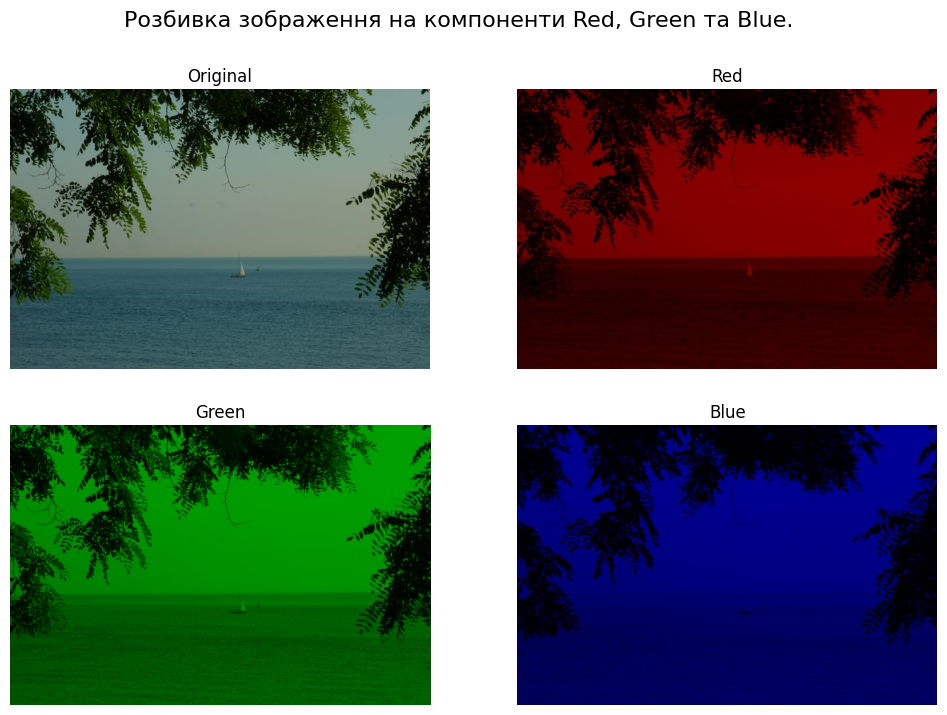

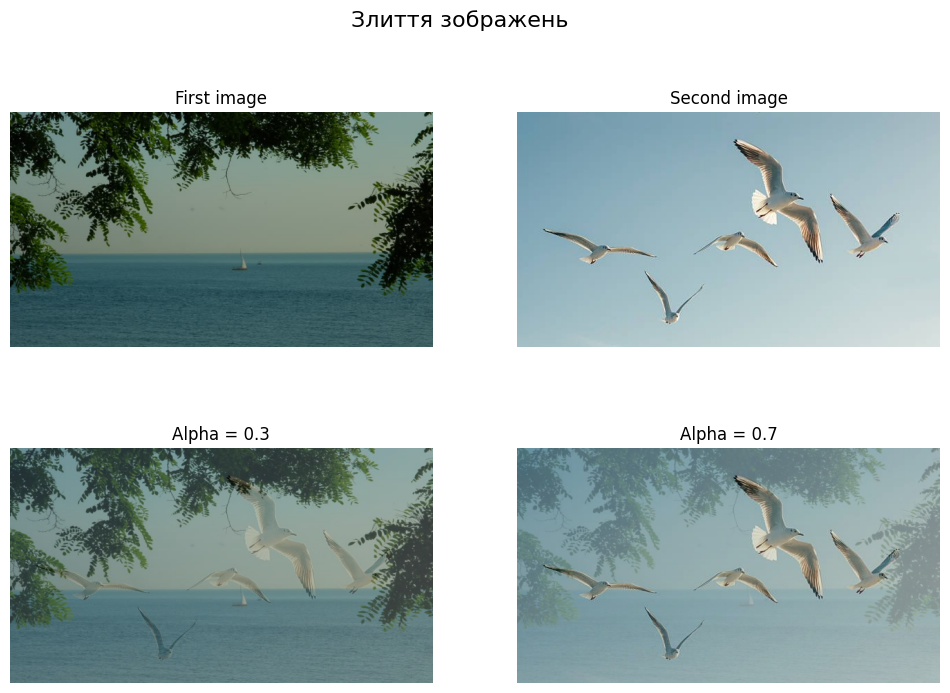

In [161]:
images = {
    'town': ('town.jpg', 2, 60, 1, 50, 'stars.jpg', 0.4, 0.6),
    'see': ('see.jpg', 0, 70, 2, 50, 'birds.jpg', 0.3, 0.7)
}

for name, params in images.items():
    
    filename, channel_1, value_1, channel_2, value_2, merge_filename, alpha_1, alpha_2 = params
    
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    main(img, channel_1, value_1, channel_2, value_2, merge_filename, alpha_1, alpha_2)

## 2. Фільтрація

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

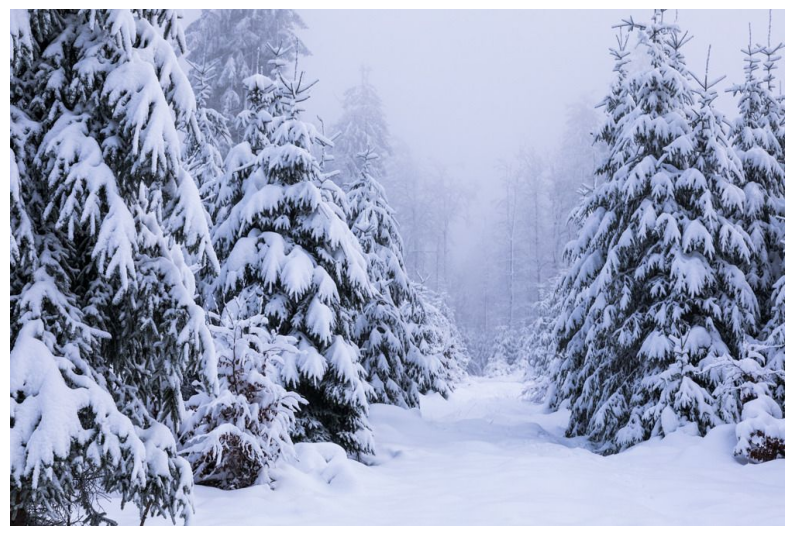

In [162]:
img = cv2.imread('winter.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")

### 2.1 Фільтер розмиття

In [163]:
filter_blur = cv2.getGaussianKernel(15, 2).flatten()
# print(filter_blur)

size = len(filter_blur)
img_h, img_w, img_c = img.shape
pad = size // 2

blur_h = np.zeros_like(img, dtype=np.float32)
blur_v = np.zeros_like(img, dtype=np.float32)

for c in range(img_c):
    pad_image = np.pad(img[:, :, c], ((0, 0), (pad, pad)), mode='reflect')
    for i in range(img_h):
        for j in range(img_w):
            blur_h[i, j, c] = np.sum(pad_image[i, j:j+size ] * filter_blur)

for c in range(img_c):
    pad_image = np.pad(blur_h[:, :, c], ((pad, pad), (0, 0)), mode='reflect')
    for i in range(img_h):
        for j in range(img_w):
            blur_v[i, j, c] = np.sum(pad_image[i:i+size, j] * filter_blur)      

blur_v = np.clip(blur_v, 0, 255).astype(np.uint8)

In [164]:
blur = cv2.GaussianBlur(img, (15, 15), 0)

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

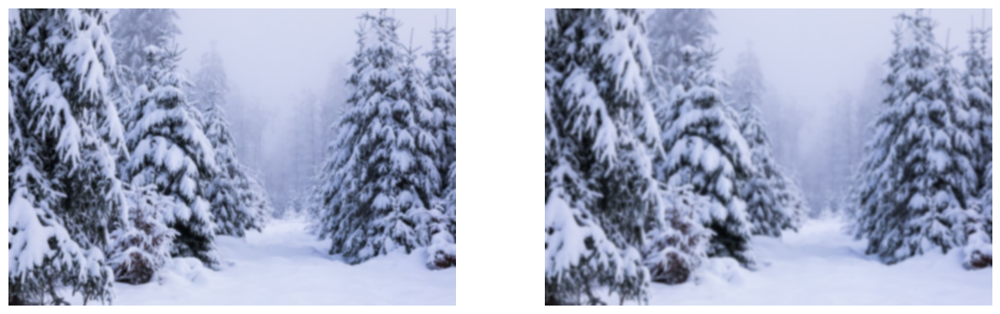

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

axes[0].imshow(blur_v)
axes[0].axis("off")  

axes[1].imshow(blur)
axes[1].axis("off")

### 2.2 Фільтр поліпшення чіткості

In [166]:
filter = np.array([[-1, -1, -1],
                     [-1, 9, -1], 
                     [-1, -1, -1]])

filter_h, filter_w = filter.shape

pad = filter_h // 2 

padded_img = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
result = np.zeros_like(img, dtype=np.float32)

for c in range(img_c):  
    for i in range(img_h):
         for j in range(img_w):
             
            region = padded_img[i:i + filter_h, j:j + filter_w, c]  
            result[i, j, c] = np.sum(region * filter)
                 
result1 = np.clip(result, 0, 255).astype(np.uint8)

In [167]:
result2 = cv2.filter2D(img, -1, filter)

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

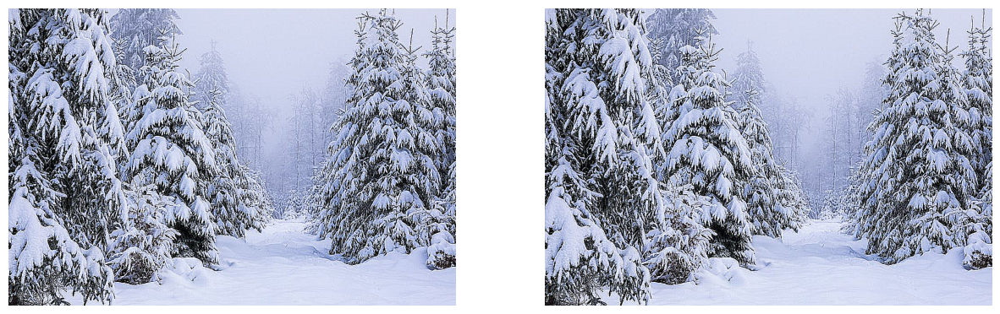

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

axes[0].imshow(result1)
axes[0].axis("off")

axes[1].imshow(result2)
axes[1].axis("off")

### 2.3 Mедіанний фільтр

In [ ]:
size_filter = 7
pad = size_filter // 2 

padded_img = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')
result1 = np.zeros_like(img) 

for c in range(img_c):  
    for i in range(img_h):
         for j in range(img_w):
             
            region = padded_img[ i:i + size_filter, j:j + size_filter , c]  
            region_list = np.ravel(region)
            region_list.sort()
            median = region_list[size_filter**2 // 2]
            result1[i, j, c] = median               

In [170]:
result2 = cv2.medianBlur(img, 7)

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

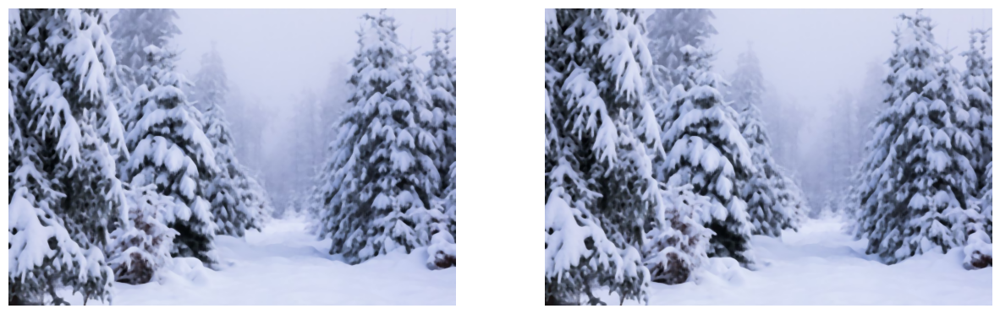

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

axes[0].imshow(result1)
axes[0].axis("off")

axes[1].imshow(result2)
axes[1].axis("off")

### 2.4 Фільтр ерозії і нарощування 

In [172]:
erosion_dilation = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
], dtype=np.uint8)

filter_h, filter_w = erosion_dilation.shape

pad = filter_h // 2 

padded_img = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='reflect')

img_erosion_1 = np.zeros_like(img)

for c in range(img_c):  
    for i in range(img_h):
         for j in range(img_w):
             
            region = padded_img[i:i + filter_h, j:j + filter_w, c]  
            img_erosion_1[i, j, c] = np.min(region[erosion_dilation == 1])
            
img_dilation_1 = np.zeros_like(img)

for c in range(img_c):  
    for i in range(img_h):
         for j in range(img_w):
             
            region = padded_img[i:i + filter_h, j:j + filter_w, c]  
            img_dilation_1[i, j, c] = np.max(region[erosion_dilation == 1])        

In [173]:
img_erosion_2 = cv2.erode(img, erosion_dilation,
                         borderType=cv2.BORDER_REFLECT)

img_dilation_2 = cv2.dilate(img, erosion_dilation,
                          borderType=cv2.BORDER_REFLECT)

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

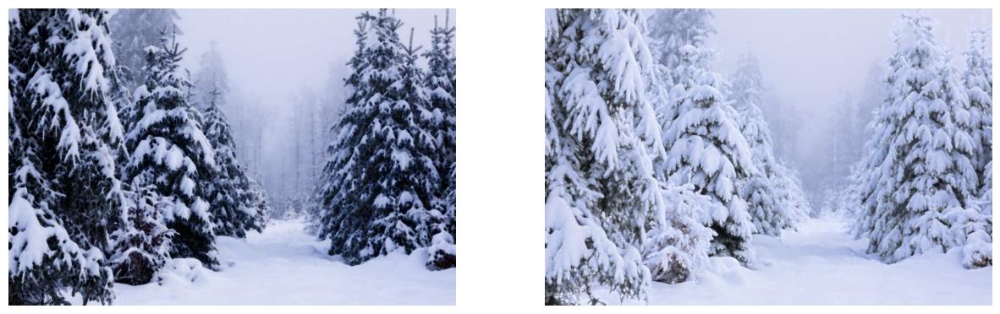

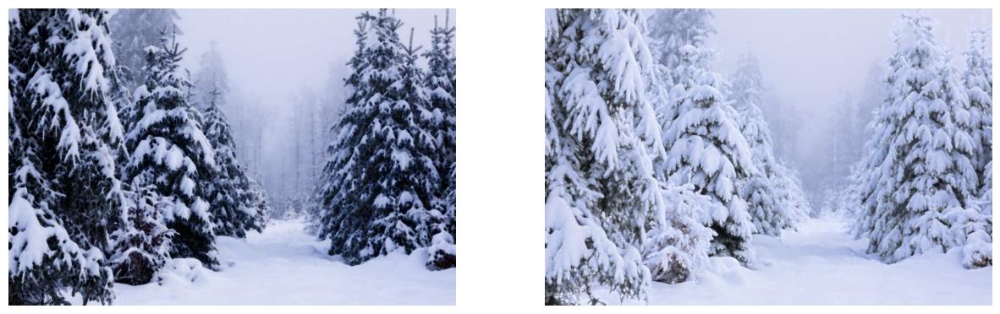

In [174]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

axes[0].imshow(img_erosion_1)
axes[0].axis("off")

axes[1].imshow(img_dilation_1)
axes[1].axis("off")

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

axes[0].imshow(img_erosion_2)
axes[0].axis("off")

axes[1].imshow(img_dilation_2)
axes[1].axis("off")

### 2.5 Фільтр Собеля

In [175]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

y = np.array([[-1, -2, -1], 
              [ 0,  0,  0], 
              [ 1,  2,  1]])

x = np.array([[-1,  0,  1],
              [-2,  0,  2], 
              [-1,  0,  1]])

filter_h, filter_w = y.shape
pad = filter_h // 2 

padded_img = np.pad(img_gray, ((pad, pad), (pad, pad)), mode='reflect')

sobel_x1 = np.zeros((img_h, img_w), dtype=np.float64) 
sobel_y1 = np.zeros((img_h, img_w), dtype=np.float64) 
sobel1 = np.zeros((img_h, img_w), dtype=np.float64) 

for i in range(img_h):
    for j in range(img_w):
        
        region = padded_img[i:i + filter_h, j:j + filter_w]  
        
        sobel_y1[i, j] = np.sum(region * y)
        sobel_x1[i, j] = np.sum(region * x)
        sobel1[i, j] = np.sqrt(sobel_x1[i, j]**2 + sobel_y1[i, j]**2)

sobel1 = (sobel1 / np.max(sobel1) * 255).astype(np.uint8)

In [176]:
sobel_x2 = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y2 = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

sobel2 = np.sqrt(sobel_x2**2 + sobel_y2**2)
sobel2 = np.clip(sobel2, 0, 255).astype(np.uint8)

(np.float64(-0.5), np.float64(999.5), np.float64(666.5), np.float64(-0.5))

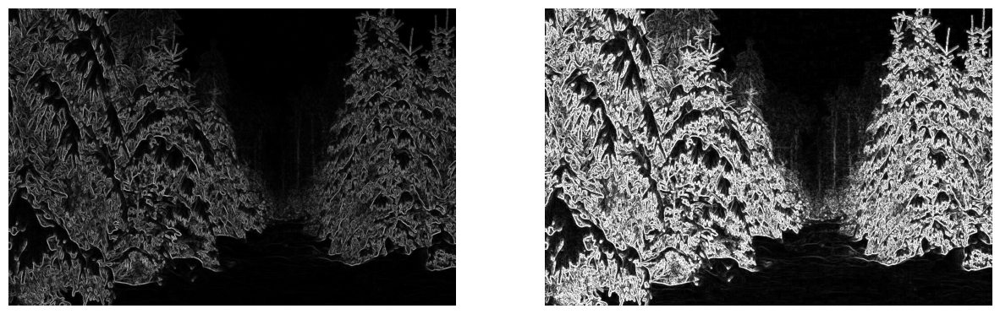

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

axes[0].imshow(sobel1, cmap='gray')
axes[0].axis("off")

axes[1].imshow(sobel2, cmap='gray')
axes[1].axis("off")

## 3. Вбудовування водяного знаку в канал Blue.

Ширина: 246
Висота: 151
Кількість каналів: 3


(np.float64(-0.5), np.float64(245.5), np.float64(150.5), np.float64(-0.5))

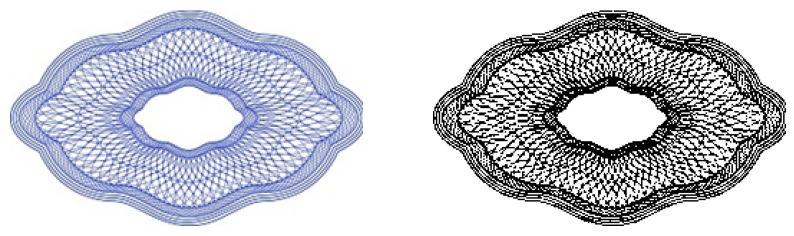

In [178]:
wm = cv2.imread('WM.png')
wm = cv2.cvtColor(wm, cv2.COLOR_BGR2RGB)

height, width, channels = wm.shape
print("Ширина:", width)
print("Висота:", height)
print("Кількість каналів:", channels)

gray_wm = cv2.cvtColor(wm, cv2.COLOR_BGR2GRAY)
_, bin_wm = cv2.threshold(gray_wm, 190, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(wm)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bin_wm, cmap="gray")
plt.axis("off")

In [179]:
def build_wm_color(image, bit_plane):

    r_channel, g_channel, b_channel = cv2.split(image)
    bit_mask = np.uint8(1 << (bit_plane - 1))

    h_img, w_img = image.shape[:2]
    h_wm, w_wm = bin_wm.shape[:2]

    wm = np.tile( bin_wm, (int(np.ceil(h_img / h_wm)),  int(np.ceil(w_img / w_wm))))
    wm = wm[:h_img, :w_img]

    b_channel = (b_channel & ~bit_mask) | ((wm == 0) * bit_mask)
    new_image = cv2.merge([r_channel, g_channel, b_channel])

    return new_image

In [ ]:
img = cv2.imread('flowers.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [181]:
new_image = build_wm_color(img, 7)

(np.float64(-0.5), np.float64(364.5), np.float64(209.5), np.float64(-0.5))

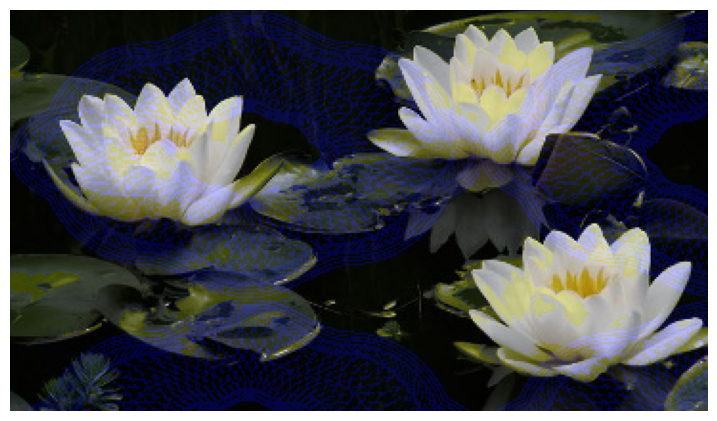

In [182]:
plt.figure(figsize=(9, 6))
plt.imshow(new_image)
plt.axis("off")